# Impact of LLMs on Spoken Word Communication


In [ ]:
# Current setting in the notebook:
# TRANSCRIPT_COL = None

# Example if your transcripts are in a column named 'transcript_text'
# TRANSCRIPT_COL = 'transcript_text'

# After uploading your files and adjusting TRANSCRIPT_COL if necessary,
# you should re-run the code cells under sections '1. Load Corpora from Cleaned CSVs' and onward.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# Update CLEANED_CSV_DIR with the correct case-sensitive path
CLEANED_CSV_DIR = Path("/content/drive/MyDrive/COG403/final/csv")

print(f"CLEANED_CSV_DIR set to: {CLEANED_CSV_DIR}")
if not CLEANED_CSV_DIR.exists():
    print(f"Warning: {CLEANED_CSV_DIR} still does not exist. Please check if 'final' or 'csv' are also capitalized.")

CLEANED_CSV_DIR set to: /content/drive/MyDrive/COG403/final/csv


## 0. Imports & Config

In [ ]:
import re
import math
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

### Word Lists

- **TARGET_WORDS**: LLM-associated words drawn from Anderson et al. (2025). These words were shown to increase after ChatGPT's release.
- **CONTROL_WORDS**: Synonyms of each target word, used to detect lexical drift vs genuine LLM influence.
- Inflected forms (e.g. *boasts*, *boasted*) are collapsed to their lemma at tokenization time.

In [ ]:
# Target words (LLM-associated) from Anderson et al. 2025
TARGET_WORDS = [
    "delve", "comprehend", "boast", "meticulous", "commendable",
    "pivotal", "intricate", "notable", "leverage", "underscore",
    "nuance", "facilitate", "robust", "adept", "paramount",
    "elucidate", "exemplify", "foster", "holistic", "imperative",
    "innovative", "multifaceted", "proactive", "seamless", "synergy",
    "transformative", "uncover", "utilize", "vibrant", "groundbreaking",
    "encompass", "reimagine"
]

#  Control words (synonyms of target words)
# Each word is a synonym that maps to a target word for pairing in the t-test
# Keys = control word, values = the target word it is paired with
CONTROL_PAIRS = {
    "explore":      "delve",
    "understand":   "comprehend",
    "feature":      "boast",
    "careful":      "meticulous",
    "praiseworthy": "commendable",
    "crucial":      "pivotal",
    "complex":      "intricate",
    "significant":  "notable",
    "use":          "leverage",
    "emphasize":    "underscore",
    "detail":       "nuance",
    "enable":       "facilitate",
    "strong":       "robust",
    "skilled":      "adept",
    "supreme":      "paramount",
    "explain":      "elucidate",
    "illustrate":   "exemplify",
    "support":      "foster",
    "comprehensive":"holistic",
    "necessary":    "imperative",
    "creative":     "innovative",
    "diverse":      "multifaceted",
    "forward-thinking": "proactive",
    "smooth":       "seamless",
    "cooperation":  "synergy",
    "significant":  "transformative",
    "reveal":       "uncover",
    "employ":       "utilize",
    "lively":       "vibrant",
    "novel":        "groundbreaking",
    "include":      "encompass",
    "rethink":      "reimagine",
}

CONTROL_WORDS = list(CONTROL_PAIRS.keys())

# All words of interest
ALL_WORDS_OF_INTEREST = set(TARGET_WORDS + CONTROL_WORDS)

print(f"Target words  : {len(TARGET_WORDS)}")
print(f"Control words : {len(CONTROL_WORDS)}")

Target words  : 32
Control words : 31


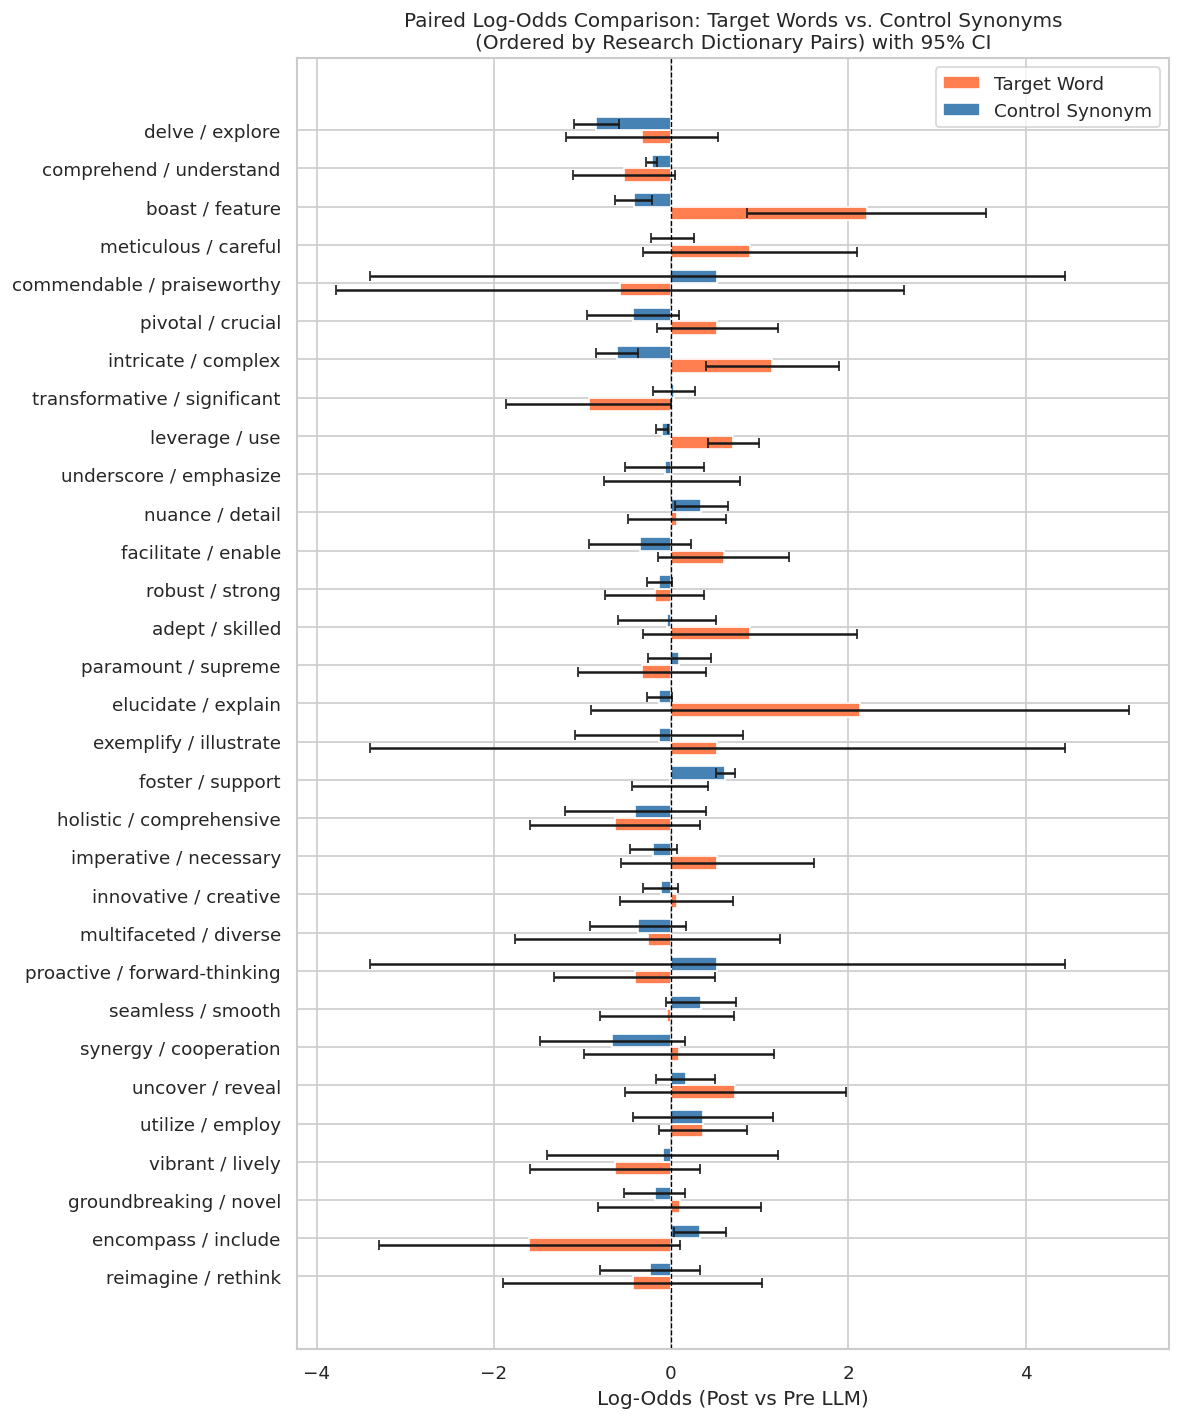

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data based on the CONTROL_PAIRS dictionary
paired_data = []
for ctrl, trgt in CONTROL_PAIRS.items():
    if trgt in freq_df.index and ctrl in freq_df.index:
        paired_data.append({
            'target_word': trgt,
            'control_word': ctrl,
            'target_lo': freq_df.loc[trgt, 'log_odds'],
            'control_lo': freq_df.loc[ctrl, 'log_odds'],
            'target_se': freq_df.loc[trgt, 'se_log_odds'],
            'control_se': freq_df.loc[ctrl, 'se_log_odds']
        })

# Create the plot
fig, ax = plt.subplots(figsize=(10, 12))

y_pos = np.arange(len(paired_data))
height = 0.35

target_values = [d['target_lo'] for d in paired_data]
control_values = [d['control_lo'] for d in paired_data]
labels = [f"{d['target_word']} / {d['control_word']}" for d in paired_data]

# Calculate error bar values (e.g., 95% CI is approx log-odds ± 1.96 * SE)
Z_SCORE = 1.96 # For 95% confidence interval
target_errors = [d['target_se'] * Z_SCORE for d in paired_data]
control_errors = [d['control_se'] * Z_SCORE for d in paired_data]

ax.barh(y_pos + height/2, target_values, height, label='Target Word', color='coral', xerr=target_errors, capsize=3)
ax.barh(y_pos - height/2, control_values, height, label='Control Synonym', color='steelblue', xerr=control_errors, capsize=3)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # Match the order of the dictionary from top to bottom
ax.set_xlabel('Log-Odds (Post vs Pre LLM)')
ax.set_title('Paired Log-Odds Comparison: Target Words vs. Control Synonyms\n(Ordered by Research Dictionary Pairs) with 95% CI')
ax.legend()

plt.tight_layout()
plt.show()

### Lemmatization Map
Inflected forms are collapsed to their base form so that *boasts*, *boasted*, *boasting* all count toward *boast*.

In [ ]:
LEMMA_MAP = {
    "realms": "realm",
    "potentials": "potential",
    "emphasizes": "emphasize", "emphasized": "emphasize", "emphasizing": "emphasize",
    "emphasise": "emphasize", "emphasises": "emphasize", "emphasised": "emphasize",
    "comprehends": "comprehend", "comprehended": "comprehend", "comprehending": "comprehend", "comprehension": "comprehend",
    "showcases": "showcase", "showcased": "showcase", "showcasing": "showcase",
    "advancements": "advancement", "advance": "advancement", "advances": "advancement", "advanced": "advancement",
    "aligns": "align", "aligned": "align", "aligning": "align", "alignment": "align", "alignments": "align",
    "delves": "delve", "delved": "delve", "delving": "delve",
    "notably": "notable",
    "garners": "garner", "garnered": "garner", "garnering": "garner",
    "strategic": "strategically",
    "meticulously": "meticulous",
    "boasts": "boast", "boasted": "boast", "boasting": "boast",
    "surpasses": "surpass", "surpassed": "surpass", "surpassing": "surpass",
    "highlights": "highlight", "highlighted": "highlight", "highlighting": "highlight",
    "coordinates": "coordinate", "coordinated": "coordinate", "coordinating": "coordinate",
    "collects": "collect", "collected": "collect", "collecting": "collect",
    "explores": "explore", "explored": "explore", "exploring": "explore",
    "exceeds": "exceed", "exceeded": "exceed", "exceeding": "exceed",
    "features": "feature", "featured": "feature",
    "displays": "display", "displayed": "display", "displaying": "display",
    "understands": "understand", "understood": "understand", "understanding": "understand",
    "progresses": "progress", "progressed": "progress", "progressing": "progress",
}

def lemmatize(token: str) -> str:
    return LEMMA_MAP.get(token, token)

## 1. Load Corpora from Cleaned CSVs

In [ ]:
import os
from pathlib import Path

def check_dir(path):
    path_obj = Path(path)
    if path_obj.exists():
        print(f"Checking: {path_obj}")
        files = os.listdir(path_obj)
        if not files:
            print("  [Folder is empty]")
        else:
            for f in files:
                print(f"  - {f}")
    else:
        print(f"Directory does not exist: {path_obj}")

print("--- Pre-LLM Directory ---")
check_dir(CLEANED_CSV_DIR / "pre")
print("\n--- Post-LLM Directory ---")
check_dir(CLEANED_CSV_DIR / "post")

## 8. Category-Specific Analysis
This section calculates the aggregate frequency of all target words within each category to identify which areas show the most significant lexical shifts.

### 9. Dataset Balance: Transcript Counts by Category
This checks if one period is heavily skewed toward certain categories compared to the other.

In [ ]:
import pandas as pd

# Let's look at the first 5 rows of a post-LLM file to see how columns are structured
post_files = list(POST_DIR.glob('*.csv'))
if post_files:
    for path in post_files[:3]: # Check first 3 files
        print(f"--- File: {path.name} ---")
        try:
            test_df = pd.read_csv(path, nrows=5, on_bad_lines='skip')
            print(f"Columns: {test_df.columns.tolist()}")
            display(test_df.head(2))
        except Exception as e:
            print(f"Error reading {path.name}: {e}")
else:
    print("No CSV files found in the post directory.")

In [ ]:
# 1. Configuration & Global Constants
VALID_CATEGORIES = ['Film & Animation', 'Autos & Vehicles', 'Music', 'Pets & Animals', 'Sports', 'Short Movies', 'Travel & Events', 'Gaming', 'Videoblogging', 'People & Blogs', 'Comedy', 'Entertainment', 'News & Politics', 'Howto & Style', 'Education', 'Science & Technology', 'Nonprofits & Activism', 'Movies', 'Anime/Animation', 'Action/Adventure', 'Classics', 'Comedy', 'Documentary', 'Drama', 'Family', 'Foreign', 'Horror', 'Sci-Fi/Fantasy', 'Thriller', 'Shorts', 'Shows', 'Trailers']

TRANSCRIPT_COL = 'subtitles'
CATEGORY_COL = 'category'
PRE_DIR = CLEANED_CSV_DIR / 'pre'
POST_DIR = CLEANED_CSV_DIR / 'post'

In [ ]:
import math
import re
import pandas as pd
from collections import Counter
from pathlib import Path

def log_odds(c_post, N_post, c_pre, N_pre, smoothing=0.5):
    p_post = (c_post + smoothing) / (N_post + smoothing)
    p_pre = (c_pre + smoothing) / (N_pre + smoothing)
    return math.log(p_post / (1 - p_post)) - math.log(p_pre / (1 - p_pre))

def se_log_odds(c_post, N_post, c_pre, N_pre, smoothing=0.5):
    # Standard Error of log-odds ratio (using Woolf's method with continuity correction)
    # Source: https://stats.stackexchange.com/questions/59239/standard-error-of-log-odds-ratio
    term_pre = 1 / (c_pre + smoothing) + 1 / (N_pre - c_pre + smoothing)
    term_post = 1 / (c_post + smoothing) + 1 / (N_post - c_post + smoothing)
    return math.sqrt(term_pre + term_post)

def tokenize(text):
    tokens = re.findall(r"\b\w+\b", str(text).lower())
    return [lemmatize(t) for t in tokens]

def get_fallback_category(file_path: Path):
    """Determines category from filename if the CSV column is malformed."""
    fname = file_path.name.lower()
    if 'edu' in fname: return 'Education'
    if 'ent' in fname: return 'Entertainment'
    if 'news' in fname: return 'News & Politics'
    if 'sci' in fname: return 'Science & Technology'
    if 'comedy' in fname: return 'Comedy'
    if 'people' in fname: return 'People & Blogs'
    return 'Unknown'

def clean_leaked_transcripts(df: pd.DataFrame, category_col: str, transcript_col: str, file_path: Path) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    # If the category column is missing or full of transcript leaks, use fallback
    if category_col not in df.columns:
        df[category_col] = get_fallback_category(file_path)
    else:
        # Identify rows where the category is actually a valid label
        is_valid = df[category_col].isin(VALID_CATEGORIES)
        # For invalid rows, overwrite with the filename fallback
        fallback = get_fallback_category(file_path)
        df.loc[~is_valid, category_col] = fallback

    return df

def load_corpus_by_category(folder: Path, transcript_col, cat_col):
    cat_data = {}
    total_tokens = 0
    all_counts = Counter()
    for path in sorted(folder.glob("*.csv")):
        df = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
        df = clean_leaked_transcripts(df, cat_col, transcript_col, path)
        if transcript_col not in df.columns: continue
        for _, row in df.iterrows():
            cat = str(row[cat_col])
            if cat not in cat_data: cat_data[cat] = {'counts': Counter(), 'N': 0}
            tokens = tokenize(row[transcript_col])
            n = len(tokens)
            cat_data[cat]['counts'].update(tokens)
            cat_data[cat]['N'] += n
            all_counts.update(tokens)
            total_tokens += n
    return all_counts, total_tokens, cat_data

In [ ]:
# Re-run the pipeline with the new fallback logic
pre_counts, pre_N, pre_cats = load_corpus_by_category(PRE_DIR, TRANSCRIPT_COL, CATEGORY_COL)
post_counts, post_N, post_cats = load_corpus_by_category(POST_DIR, TRANSCRIPT_COL, CATEGORY_COL)

freq_df = pd.DataFrame([{
    'word': w,
    'type': 'target' if w in TARGET_WORDS else 'control',
    'c_pre': pre_counts[w],
    'c_post': post_counts[w],
    'log_odds': log_odds(post_counts[w], post_N, pre_counts[w], pre_N)
} for w in TARGET_WORDS + CONTROL_WORDS]).set_index('word')

print(f"Pipeline complete with fallback logic.\nPre-LLM Tokens: {pre_N}\nPost-LLM Tokens: {post_N}")
display(freq_df.sort_values('log_odds', ascending=False).head(10))

Pipeline complete with fallback logic.
Pre-LLM Tokens: 7070331
Post-LLM Tokens: 4192410


,type,c_pre,c_post,log_odds
word,,,,
boast,target,2,13,2.209033
elucidate,target,0,2,2.132070
intricate,target,10,19,1.141674
adept,target,4,6,0.890357
meticulous,target,4,6,0.890357
uncover,target,4,5,0.723303
leverage,target,86,103,0.702071
support,control,633,691,0.610310
facilitate,target,13,14,0.594092


In [ ]:
def clean_leaked_transcripts(df: pd.DataFrame, category_col: str, transcript_col: str) -> pd.DataFrame:
    """
    Simplified cleaning: Only keep rows where the category is explicitly valid.
    Discard rows where transcript fragments leaked into the category column.
    """
    if df.empty:
        return df

    # Keep only rows where the category is in our known valid list
    is_valid = df[category_col].isin(VALID_CATEGORIES)
    cleaned_df = df[is_valid].copy()

    return cleaned_df

In [ ]:
pre_doc_counts = count_transcripts_by_cat(PRE_DIR, CATEGORY_COL)
post_doc_counts = count_transcripts_by_cat(POST_DIR, CATEGORY_COL)

all_cats = sorted(set(pre_doc_counts.keys()) | set(post_doc_counts.keys()))
skew_df = pd.DataFrame([{'Category': c, 'Pre-LLM Count': pre_doc_counts[c], 'Post-LLM Count': post_doc_counts[c]} for c in all_cats])

print("Transcript Counts after skipping all invalid category rows:")
display(skew_df.sort_values('Post-LLM Count', ascending=False))

In [ ]:
def count_transcripts_by_cat(folder: Path, cat_col):
    """
    Counts the number of unique transcripts (rows) per category
    after applying strict cleaning.
    """
    cat_counts = Counter()
    for path in sorted(folder.glob("*.csv")):
        try:
            df = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
            df = clean_leaked_transcripts(df, cat_col, TRANSCRIPT_COL)
            if not df.empty:
                cat_counts.update(df[cat_col].astype(str))
        except Exception:
            continue
    return cat_counts

In [ ]:

file_path = CLEANED_CSV_DIR / 'post' / 'PostGPTEnt.csv'
if file_path.exists():
    # Reading with no filtering and showing the first row's columns and values
    df_raw = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')
    print(f"Raw columns found: {df_raw.columns.tolist()}")
    print("\n--- First Row Raw Content ---")
    display(df_raw.head(1))

    first_cat = df_raw.iloc[0]['category'] if 'category' in df_raw.columns else 'N/A'
    print(f"\nValue in 'category' column: {first_cat}")
else:
    print(f"File not found at {file_path}")

In [ ]:
file_path = CLEANED_CSV_DIR / 'post' / 'PostGPTEnt.csv'
if file_path.exists():
    print("--- Raw File Content (First 3 Lines) ---")
    with open(file_path, 'r', encoding='utf-8') as f:
        for i in range(3):
            print(f"Line {i}: {f.readline().strip()}")
else:
    print("File not found.")

In [ ]:
file_path = CLEANED_CSV_DIR / 'post' / 'PostGPTEnt.csv'
if file_path.exists():
    df_debug = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')
    # Check which rows have a 'valid' category vs 'leaked' transcript text
    df_debug['is_leaked'] = ~df_debug[CATEGORY_COL].isin(VALID_CATEGORIES)

    summary = df_debug['is_leaked'].value_counts().to_dict()
    print(f"--- Column Shift Analysis for {file_path.name} ---")
    print(f"Correct Category Rows: {summary.get(False, 0)}")
    print(f"Shifted/Leaked Rows: {summary.get(True, 0)}")

    if summary.get(True, 0) > 0:
        print("\nExample of a 'Shifted' row where transcript text leaked into the category column:")
        display(df_debug[df_debug['is_leaked']].head(1))
else:
    print('File not found.')

In [ ]:
import pandas as pd
from pathlib import Path

# Diagnostic check for Post-LLM Entertainment files
ent_files = [f for f in POST_DIR.glob('*.csv') if 'Ent' in f.name]

print(f"--- Diagnostic Report for Entertainment Files ---")
for path in ent_files:
    df_raw = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
    raw_count = len(df_raw)

    # Check category distribution in raw file
    raw_cats = df_raw[CATEGORY_COL].value_counts() if CATEGORY_COL in df_raw.columns else 'Column Missing'

    # Apply cleaning - updated to pass the path for fallback logic
    df_cleaned = clean_leaked_transcripts(df_raw, CATEGORY_COL, TRANSCRIPT_COL, path)
    clean_count = len(df_cleaned)

    print(f"\nFile: {path.name}")
    print(f"  - Raw rows in CSV: {raw_count}")
    print(f"  - Rows after applying cleaning/fallback: {clean_count}")
    print(f"  - Top 3 Raw Categories found: {raw_cats.head(3) if isinstance(raw_cats, pd.Series) else raw_cats}")

print("\nNote: The fallback logic ensures that rows with shifted text are correctly assigned based on the file name.")

### Integration with `load_corpus_by_category`

To integrate this cleaning step, you would modify the `load_corpus_by_category` function to call `clean_leaked_transcripts` *after* loading each CSV file and *before* processing its rows. Here's how you could adjust the `load_corpus_by_category` function:

```python
def load_corpus_by_category(folder: Path, transcript_col, cat_col):
    word_counts = Counter()
    total_tokens = 0
    cat_data = {}

    csv_files = sorted(folder.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    for path in csv_files:
        df = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
        
        # *** NEW: Apply the cleaning function here ***
        df = clean_leaked_transcripts(df, cat_col, transcript_col)

        if transcript_col not in df.columns:
            continue

        for _, row in df.iterrows():
            cat = str(row[cat_col]) if cat_col in df.columns else 'Unknown'

            # Original DATA CLEANING: If category is too long, it's probably leaked text
            # This might become redundant if clean_leaked_transcripts handles all leaks,
            # but can be kept as an additional safeguard.
            if len(cat) > MAX_CAT_LEN:
                cat = 'Unknown'

            if cat not in cat_data:
                cat_data[cat] = {'counts': Counter(), 'N': 0}

            text_content = str(row[transcript_col])
            tokens = tokenize(text_content)
            n = len(tokens)

            word_counts.update(tokens)
            total_tokens += n

            cat_data[cat]['counts'].update(tokens)
            cat_data[cat]['N'] += n

    return word_counts, total_tokens, cat_data
```

**Note:** You would need to re-run the cell where `load_corpus_by_category` is defined (`o-6EurEbByFU`) after adding this `clean_leaked_transcripts` function and then re-run the subsequent cells that depend on `pre_counts`, `post_counts`, etc.

In [ ]:
pre_counts, pre_N, pre_cats = load_corpus_by_category(PRE_DIR, TRANSCRIPT_COL, CATEGORY_COL)
post_counts, post_N, post_cats = load_corpus_by_category(POST_DIR, TRANSCRIPT_COL, CATEGORY_COL)
print(f"Reloaded with strict filtering! Post Entertainment tokens: {post_cats.get('Entertainment', {}).get('N', 0)}")

In [ ]:
print("--- Diagnostic: Investigating 'Unknown' and Fragment Categories ---")
post_files = list(POST_DIR.glob('*.csv'))

for path in post_files:
    try:
        df = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip')
        # Check how many rows have 'Entertainment' vs other things
        if CATEGORY_COL in df.columns:
            counts = df[CATEGORY_COL].value_counts().head(3)
            if 'Entertainment' not in df[CATEGORY_COL].values and len(df) > 10:
                 print(f"\nFile: {path.name}")
                 print(f"  Total Rows: {len(df)}")
                 print(f"  Top Category Values: {counts.to_dict()}")
                 print(f"  Example Transcript snippet: {str(df[TRANSCRIPT_COL].iloc[0])[:100]}...")
    except Exception as e:
        continue

In [ ]:
cat_rows = []
common_cats = set(pre_cats.keys()).intersection(post_cats.keys())
for cat in sorted(common_cats):
    if cat == 'Unknown': continue
    pre_cat_total = pre_cats[cat]['N']
    pre_target_sum = sum(pre_cats[cat]['counts'][w] for w in TARGET_WORDS)
    pre_freq = (pre_target_sum / pre_cat_total * 100000) if pre_cat_total > 0 else 0

    post_cat_total = post_cats[cat]['N']
    post_target_sum = sum(post_cats[cat]['counts'][w] for w in TARGET_WORDS)
    post_freq = (post_target_sum / post_cat_total * 100000) if post_cat_total > 0 else 0

    cat_rows.append({
        'Category': cat,
        'Pre-LLM Freq': pre_freq,
        'Post-LLM Freq': post_freq,
        'Change': post_freq - pre_freq
    })

cat_df = pd.DataFrame(cat_rows)
print("Target Word Frequency per 100k tokens (by Category):")
display(cat_df.sort_values('Change', ascending=False))

In [ ]:
if not cat_df.empty:
    # Reduced width from 12 to 6 for a thinner graph
    plt.figure(figsize=(6, 6))
    df_melted = cat_df.melt(id_vars='Category', value_vars=['Pre-LLM Freq', 'Post-LLM Freq'],
                            var_name='Period', value_name='Frequency')

    sns.barplot(data=df_melted, x='Category', y='Frequency', hue='Period')
    plt.title("Target Word Usage by Category")
    plt.ylabel("Frequency per 100k tokens")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No common categories found between periods.")

## 2. Normalized Frequencies  
`P(w|C) = c_w / N_C`

This gives the proportion of the corpus each word occupies — used for preliminary inspection.

In [31]:
def normalized_freq(word: str, counts: Counter, total: int) -> float:
    """P(w|C) = c_w / N_C"""
    return counts[word] / total if total > 0 else 0.0

rows = []
for word in TARGET_WORDS + CONTROL_WORDS:
    word_type = "target" if word in TARGET_WORDS else "control"
    c_pre  = pre_counts[word]
    c_post = post_counts[word]
    rows.append({
        "word":      word,
        "type":      word_type,
        "c_pre":     c_pre,
        "c_post":    c_post,
        "freq_pre":  normalized_freq(word, pre_counts,  pre_N),
        "freq_post": normalized_freq(word, post_counts, post_N),
    })

freq_df = pd.DataFrame(rows).set_index("word")
freq_df["freq_change"] = freq_df["freq_post"] - freq_df["freq_pre"]

print(freq_df.sort_values("freq_change", ascending=False).to_string())

                     type  c_pre  c_post      freq_pre     freq_post   freq_change
word                                                                              
support           control    633     691  8.952905e-05  1.648217e-04  7.529262e-05
leverage           target     86     103  1.216350e-05  2.456821e-05  1.240470e-05
include           control    101      83  1.428505e-05  1.979768e-05  5.512637e-06
detail            control     95      79  1.343643e-05  1.884358e-05  5.407148e-06
intricate          target     10      19  1.414361e-06  4.531999e-06  3.117639e-06
smooth            control     53      44  7.496113e-06  1.049516e-05  2.999044e-06
boast              target      2      13  2.828722e-07  3.100842e-06  2.817970e-06
reveal            control     83      58  1.173920e-05  1.383452e-05  2.095329e-06
utilize            target     33      28  4.667391e-06  6.678736e-06  2.011345e-06
pivotal            target     16      16  2.262978e-06  3.816421e-06  1.553443e-06
faci

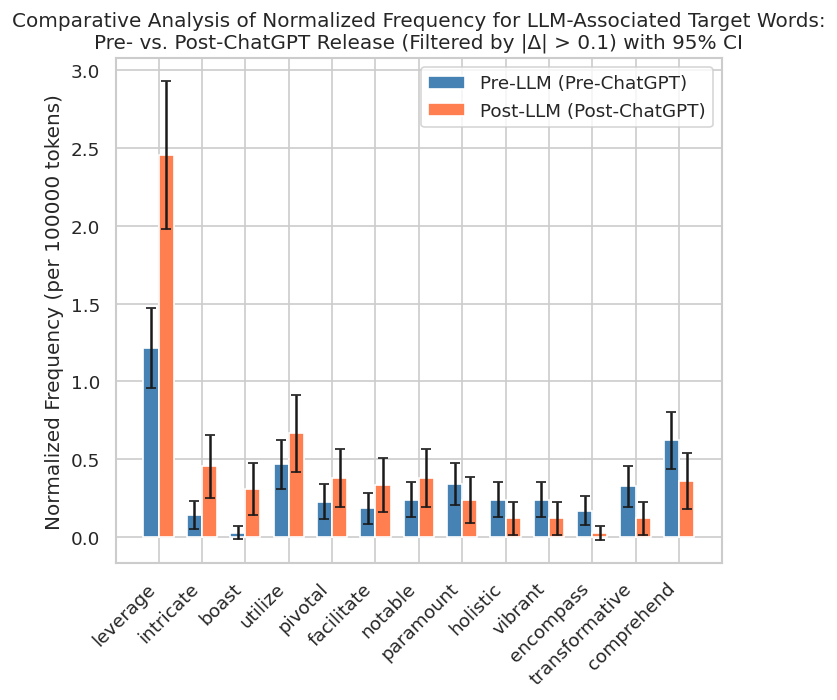

In [33]:
# Re-calculate normalized frequencies as they were overwritten in the previous step
freq_df['freq_pre'] = freq_df['c_pre'] / pre_N
freq_df['freq_post'] = freq_df['c_post'] / post_N
freq_df['freq_change'] = freq_df['freq_post'] - freq_df['freq_pre']

# Calculate standard errors for frequencies
# The formula is for binomial proportion standard error: sqrt(p * (1-p) / N)
# Add a small epsilon to prevent potential NaN if freq is exactly 0 or 1, although unlikely with these data.
epsilon = 1e-9
freq_df['se_freq_pre'] = np.sqrt(freq_df['freq_pre'] * (1 - freq_df['freq_pre'] + epsilon) / pre_N)
freq_df['se_freq_post'] = np.sqrt(freq_df['freq_post'] * (1 - freq_df['freq_post'] + epsilon) / post_N)

# Threshold for inclusion: Change in frequency must be > 0.1 per 10^5 tokens
THRESHOLD = 0.1
plot_df = freq_df[freq_df['type'] == 'target'].copy()
plot_df['abs_change'] = (plot_df['freq_post'] - plot_df['freq_pre']).abs() * 1e5
plot_df = plot_df[plot_df['abs_change'] > THRESHOLD].sort_values('freq_change', ascending=False)

x = np.arange(len(plot_df))
width = 0.35

# Z-score for 95% confidence interval (approx. 1.96 for a two-sided test)
Z_SCORE_FOR_FREQ_ERRORS = 1.96

# Calculate error bar values for the plot (scaled by 1e5)
pre_errors = plot_df['se_freq_pre'] * Z_SCORE_FOR_FREQ_ERRORS * 1e5
post_errors = plot_df['se_freq_post'] * Z_SCORE_FOR_FREQ_ERRORS * 1e5

# Width reduced to 6 for a compact academic look
fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(x - width/2, plot_df['freq_pre']  * 1e5, width, label='Pre-LLM (Pre-ChatGPT)',  color='steelblue', yerr=pre_errors, capsize=3)
ax.bar(x + width/2, plot_df['freq_post'] * 1e5, width, label='Post-LLM (Post-ChatGPT)', color='coral', yerr=post_errors, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha='right')
ax.set_ylabel('Normalized Frequency (per 100000 tokens)')
ax.set_title(f'Comparative Analysis of Normalized Frequency for LLM-Associated Target Words:\nPre- vs. Post-ChatGPT Release (Filtered by |Δ| > {THRESHOLD}) with 95% CI')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Log-Odds Ratios

$$\text{log-odds}(w) = \log\!\left(\frac{c_{\text{post}}\,/\,(N_{\text{post}} - c_{\text{post}})}{c_{\text{pre}}\,/\,(N_{\text{pre}} - c_{\text{pre}})}\right)$$

- **Positive** → word is over-represented in the post-LLM corpus  
- **Negative** → word is over-represented in the pre-LLM corpus

In [ ]:
import pandas as pd # Import pandas here to ensure it's available

# The 'log_odds' function is now defined in cell 'a0ec51a3' (Imports & Config) and available globally.
# import math # No longer needed here as it's imported in a0ec51a3

freq_df = pd.DataFrame([
    {
        'word': w,
        'type': 'target' if w in TARGET_WORDS else 'control',
        'c_pre': pre_counts[w],
        'c_post': post_counts[w],
        'log_odds': log_odds(post_counts[w], post_N, pre_counts[w], pre_N),
        'se_log_odds': se_log_odds(post_counts[w], post_N, pre_counts[w], pre_N) # Add standard error
    } for w in TARGET_WORDS + CONTROL_WORDS
]).set_index('word')

print("Top 10 Words by Log-Odds Shift (Post vs Pre):")
display(freq_df.sort_values('log_odds', ascending=False).head(10))

Top 10 Words by Log-Odds Shift (Post vs Pre):


,type,c_pre,c_post,log_odds,se_log_odds
word,,,,,
boast,target,2,13,2.209033,0.688531
elucidate,target,0,2,2.132070,1.549193
intricate,target,10,19,1.141674,0.382780
adept,target,4,6,0.890357,0.613244
meticulous,target,4,6,0.890357,0.613244
uncover,target,4,5,0.723303,0.635642
leverage,target,86,103,0.702071,0.145681
support,control,633,691,0.610310,0.055000
facilitate,target,13,14,0.594092,0.378206


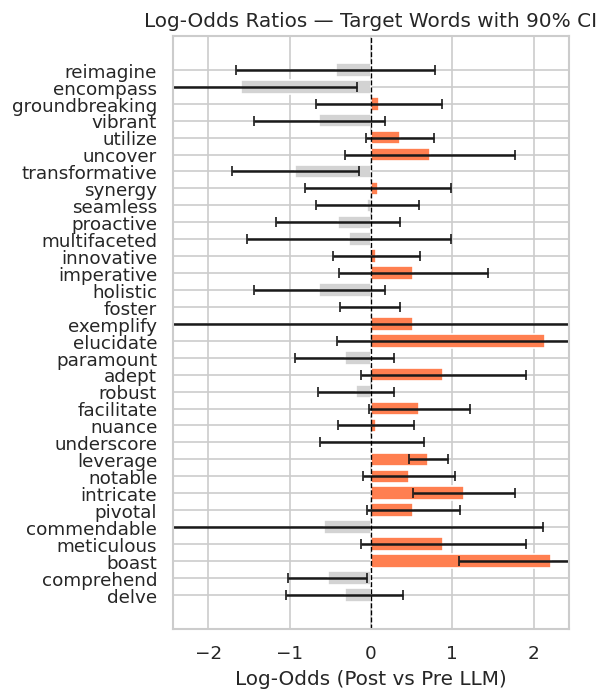

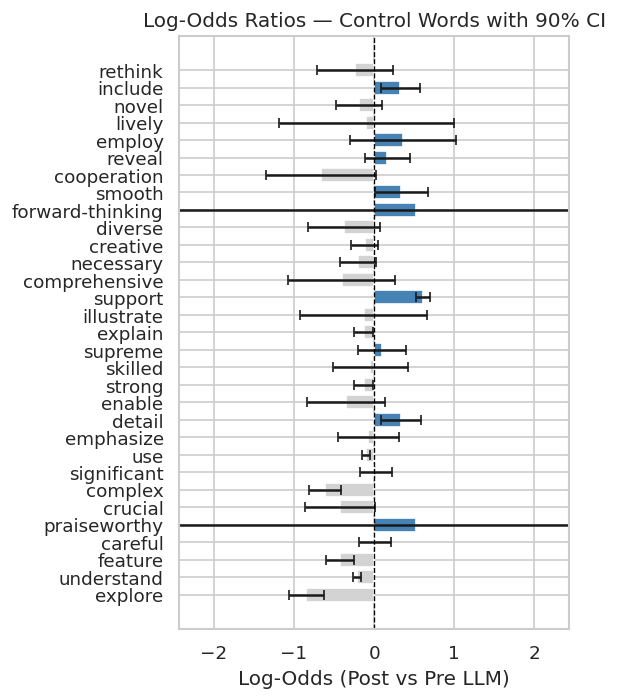

In [ ]:
# ── Separate Plots: log-odds for target and control words (Filtered) ───────────────────────
# Applying the same filtering: absolute change > 0.1 per 10^5 tokens

# Ensure abs_change is available in freq_df
freq_df['abs_change'] = (freq_df['c_post']/post_N - freq_df['c_pre']/pre_N).abs() * 1e5

# Compute shared x-axis limits
max_abs = freq_df["log_odds"].abs().max()
xlim = (-max_abs * 1.1, max_abs * 1.1)

Z_SCORE = 1.645 # For 90% confidence interval

for word_type, color in [("target", "coral"), ("control", "steelblue")]:
    subset = freq_df[(freq_df["type"] == word_type)]

    # Calculate error bars for the subset
    errors = subset["se_log_odds"] * Z_SCORE

    plt.figure(figsize=(5, 6))
    plt.barh(subset.index, subset["log_odds"], color=[
        color if v >= 0 else "lightgrey" for v in subset["log_odds"]
    ], xerr=errors, capsize=3)
    plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
    plt.xlim(xlim)
    plt.title(f"Log-Odds Ratios — {word_type.title()} Words with 90% CI")
    plt.xlabel("Log-Odds (Post vs Pre LLM)")
    plt.tight_layout()
    plt.show()

## 4. Difference-in-Proportions Test (Per Word)

For each word, tests whether the post-LLM frequency is significantly different from the pre-LLM frequency using a two-proportion z-test.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

results = []
for word, row in freq_df.iterrows():
    count  = np.array([row["c_post"], row["c_pre"]])
    nobs   = np.array([post_N,         pre_N])
    if count.sum() == 0:
        results.append({"word": word, "z_stat": np.nan, "p_value": np.nan, "significant": False})
        continue
    z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")
    results.append({
        "word":        word,
        "type":        row["type"],
        "z_stat":      z_stat,
        "p_value":     p_value,
        "significant": p_value < 0.05,
    })

prop_test_df = pd.DataFrame(results).set_index("word")
n_tests = prop_test_df["p_value"].notna().sum()
prop_test_df["p_bonferroni" ] = (prop_test_df["p_value"] * n_tests).clip(upper=1.0)
prop_test_df["sig_bonferroni"] = prop_test_df["p_bonferroni"] < 0.05

summary_df = freq_df.join(prop_test_df[["z_stat", "p_value", "significant", "p_bonferroni", "sig_bonferroni"]])
print(summary_df[["type", "c_pre", "c_post", "log_odds", "p_value", "significant"]].sort_values("p_value").head(20).to_string())

In [ ]:
# ── Volcano plot: log-odds vs -log10(p-value) ──────────────────────────────
plot_data = summary_df.dropna(subset=["p_value"]).copy()
plot_data["-log10p"] = -np.log10(plot_data["p_value"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(10, 6))
for word_type, color, marker in [("target", "coral", "o"), ("control", "steelblue", "^")]:
    sub = plot_data[plot_data["type"] == word_type]
    ax.scatter(sub["log_odds"], sub["-log10p"], color=color, marker=marker,
               label=word_type.title(), alpha=0.8, s=60)
    for word, row in sub.iterrows():
        ax.annotate(word, (row["log_odds"], row["-log10p"]),
                    fontsize=7, ha="left", va="bottom",
                    xytext=(3, 3), textcoords="offset points")

# Significance threshold lines
ax.axhline(-math.log10(0.05), color="grey", linestyle="--", linewidth=0.8, label="p=0.05")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Log-Odds (Post vs Pre LLM)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano Plot: Distributional Shift of Target and Control Words")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Paired t-Test: Target vs Control Word Growth Rates

Tests the core hypothesis: do **LLM-associated target words** grow significantly more than their **synonym controls**?

Each target word is paired with its control synonym. The test compares log-odds values across pairs.

In [ ]:
paired_rows = []
for ctrl, trgt in CONTROL_PAIRS.items():
    if trgt in freq_df.index and ctrl in freq_df.index:
        paired_rows.append({
            'target': trgt,
            'control': ctrl,
            'target_lo': freq_df.loc[trgt, 'log_odds'],
            'control_lo': freq_df.loc[ctrl, 'log_odds']
        })

paired_df = pd.DataFrame(paired_rows)
t_stat, p_val = stats.ttest_rel(paired_df['target_lo'], paired_df['control_lo'])

print(f"Final Paired t-test (Target vs Control Synonyms):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

In [ ]:
# ── Plot: paired log-odds — target vs control ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Corrected column names from target_log_odds to target_lo
ax.scatter(["Target"] * len(paired_df),  paired_df["target_lo"],
           color="coral",     s=60, alpha=0.7, zorder=3)
ax.scatter(["Control"] * len(paired_df), paired_df["control_lo"],
           color="steelblue", s=60, alpha=0.7, zorder=3)

# Draw lines connecting each pair
for _, row in paired_df.iterrows():
    ax.plot(["Target", "Control"],
            [row["target_lo"], row["control_lo"]],
            color="grey", alpha=0.4, linewidth=0.8)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_ylabel("Log-Odds (Post vs Pre LLM)")
ax.set_title(f"Paired Log-Odds: Target vs Control Words\n"
             f"t={t_stat:.3f}, p={p_val:.4f}")
plt.tight_layout()
plt.show()

## 6. Aggregate Normalized Frequency Comparison (Baseline Approach)

Alternative baseline from the paper: compute the **aggregate normalized frequency** of the full target/control word sets across pre and post corpora, then compare with a t-test across individual word frequencies.

In [ ]:
target_freq_pre  = [normalized_freq(w, pre_counts,  pre_N)  for w in TARGET_WORDS]
target_freq_post = [normalized_freq(w, post_counts, post_N) for w in TARGET_WORDS]

control_freq_pre  = [normalized_freq(w, pre_counts,  pre_N)  for w in CONTROL_WORDS]
control_freq_post = [normalized_freq(w, post_counts, post_N) for w in CONTROL_WORDS]

# t-test: do target word frequencies increase from pre to post?
t_target,  p_target  = stats.ttest_rel(target_freq_post,  target_freq_pre)
t_control, p_control = stats.ttest_rel(control_freq_post, control_freq_pre)

print("Aggregate Normalized Frequency — Paired t-tests (post vs pre)")
print(f"  Target  words: mean pre={np.mean(target_freq_pre):.2e}, "
      f"mean post={np.mean(target_freq_post):.2e}, "
      f"t={t_target:.3f}, p={p_target:.4f}")
print(f"  Control words: mean pre={np.mean(control_freq_pre):.2e}, "
      f"mean post={np.mean(control_freq_post):.2e}, "
      f"t={t_control:.3f}, p={p_control:.4f}")

## 7. Export Results

In [ ]:
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

summary_df.to_csv(output_dir / "word_summary.csv")
paired_df.to_csv(output_dir / "paired_log_odds.csv", index=False)

print("Results saved to results/")